# Clasificación de textos según los Objetivos de Desarrollo Sostenible

## Objetivo y alcance

Este notebook clasifica textos en español según los ODS con cuatro pasos:

1. preparación de los textos con bolsa de palabras y TF-IDF dentro de un pipeline;
2. modelo de tópicos LSA con `TruncatedSVD` e interpretación de tópicos;
3. comparación de dos modelos básicos de clasificación con reducción de dimensionalidad y búsqueda simple de hiperparámetros;
4. evaluación final con textos que no se usaron para entrenar.


## 1. Configuración

Se fija una semilla para que los resultados se puedan repetir. Las rutas son relativas a la carpeta del proyecto.


In [1]:
from pathlib import Path

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# Función compartida con la app (src) para que el pipeline guardado se pueda recargar
from src.text_processing import clean_corpus
from sklearn.tree import DecisionTreeClassifier

In [2]:
# Definición de Semillla para reproducibilidad 
SEED = 42
np.random.seed(SEED)

# Definición de la ruta del proyecto y del archivo de datos
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# Definición de la ruta del archivo de datos
DATA_PATH = PROJECT_ROOT / "data" / "Datos_textosODS.xlsx"
print("Semilla:", SEED)
print("Datos:", DATA_PATH.name)

Semilla: 42
Datos: Datos_textosODS.xlsx


## 2. Datos

- Se revisa lo básico: tamaño, columnas, nulos, duplicados exactos y cuántos textos hay por cada ODS.
- El archivo de datos solo tiene etiquetas de los ODS 1 a 16. No hay ejemplos del ODS 17, así que el modelo solo clasifica entre 1 y 16.
- Se aprecia un desbalance de textos con relación al ODS asignado.

In [3]:
# lectura del archivo de datos ODS
df = pd.read_excel(DATA_PATH)

# informacioón de dimension de los datos y de las columnas
print("Filas y columnas:", df.shape)
print("Columnas:", list(df.columns))

# Resumen detallado de los datos
resumen = pd.Series({
    "filas": len(df),
    "textos_nulos": df["textos"].isna().sum(),
    "etiquetas_nulas": df["ODS"].isna().sum(),
    "duplicados_exactos": df["textos"].duplicated().sum(),
    "clases_distintas": df["ODS"].nunique()
}, name="valor")
display(resumen.to_frame())

# Análisis de las clases ODS (qué falta y qué hay)
print("\nODS presentes:", sorted(df["ODS"].unique()))
print("ODS ausente:", sorted(set(range(1, 18)) - set(df["ODS"].unique())))

Filas y columnas: (9656, 2)
Columnas: ['textos', 'ODS']


,valor
filas,9656
textos_nulos,0
etiquetas_nulas,0
duplicados_exactos,0
clases_distintas,16



ODS presentes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
ODS ausente: [17]


,cantidad,porcentaje
ODS,,
1,505,5.23
2,369,3.82
3,894,9.26
4,1025,10.62
5,1070,11.08
6,695,7.20
7,787,8.15
8,446,4.62
9,343,3.55


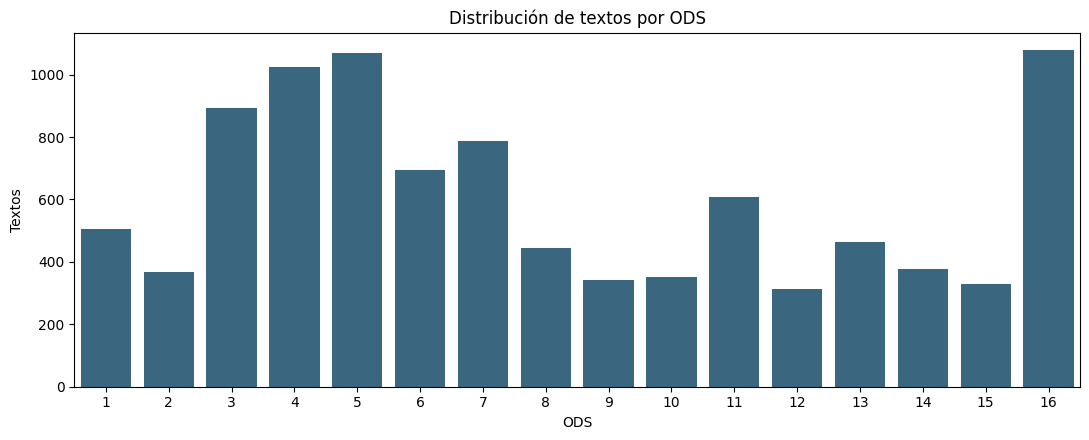

In [4]:
# Análisis de la distribución de clases ODS, su porcentaje y visualización
conteo_ods = df["ODS"].value_counts().sort_index()
distribucion = pd.DataFrame({
    "cantidad": conteo_ods,
    "porcentaje": (100 * conteo_ods / len(df)).round(2),
})
display(distribucion)

# Realizar grafico
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(x=conteo_ods.index.astype(str), y=conteo_ods.values, color="#2F6B8A", ax=ax)
ax.set(title="Distribución de textos por ODS", xlabel="ODS", ylabel="Textos")
plt.tight_layout()
plt.show()

El conjunto contiene etiquetas para los ODS 1 a 16, pero no para el ODS 17. Por ello, con esta fuente no es posible entrenar ni evaluar una clase 17. El soporte también varía entre las clases; en las siguientes fases se utilizará una partición estratificada y F1 macro como métrica principal para dar el mismo peso a cada ODS. El desbalance es notable (relación aproximada de 3.5 a 1, con dominio de los ODS 16, 5, 4 y 3), por lo que la evaluación se complementará con reporte por clase y matriz de confusión normalizada.

## 3. Separación de entrenamiento y prueba

Se separa 80% para entrenar y 20% para probar, manteniendo el porcentaje de cada ODS en ambos grupos con `stratify`. La prueba se guarda y no se toca hasta la evaluación final.


In [5]:
# Separación de los datos en entrenamiento y prueba de la base de datos, con estratificación para mantener la proporción de clases
X = df["textos"]
y = df["ODS"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED, stratify=y,)

# Información de la cantidad de datos en entrenamiento y prueba
print("Entrenamiento:", len(X_train))
print("Prueba:", len(X_test))
print()
print("Porcentaje por ODS (total / train / test):")
# Tabla comparativapara verificar que el parámetro 'stratify' funcionó correctamente
comparar = pd.DataFrame({
    "total": y.value_counts(normalize=True).sort_index() * 100,
    "train": y_train.value_counts(normalize=True).sort_index() * 100,
    "test": y_test.value_counts(normalize=True).sort_index() * 100,
}).round(2)
display(comparar)


Entrenamiento: 7724
Prueba: 1932

Porcentaje por ODS (total / train / test):


,total,train,test
ODS,,,
1,5.23,5.23,5.23
2,3.82,3.82,3.83
3,9.26,9.26,9.27
4,10.62,10.62,10.61
5,11.08,11.08,11.08
6,7.20,7.20,7.19
7,8.15,8.14,8.18
8,4.62,4.62,4.61
9,3.55,3.55,3.57


## 4. Preparación del texto y TF-IDF


Se realiza una limpieza sencilla: minúsculas, quitar enlaces web y dejar un solo espacio. Posteriormente, se emplea `TfidfVectorizer` para convertir el texto en matrices numéricas. Todo esto queda integrado dentro de un `Pipeline` para aplicar idénticamente las mismas reglas al entrenar y al predecir.

A propósito, no se quitan tildes ni se emplean listas de palabras vacías o lematización. Se busca mantener el procesamiento simple para no eliminar accidentalmente palabras que ayudan a clasificar correctamente los ODS


In [6]:
# función para limpiar el texto eliminando URLs y convirtiendo a minúsculas
URL = re.compile(r"https?://\S+|www\.\S+")
def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = URL.sub(" ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

# función para procesar un corpus de textos aplicando la función anterior de limpieza a cada texto
def procesar_corpus(textos):
    return [limpiar_texto(t) for t in textos]

# Parámetros del TF-IDF
PARAMETROS_TFIDF = {
    "lowercase": True,     # True porque clean_corpus no pasa a minúsculas (lo hace el vectorizador)
    "ngram_range": (1, 2), # Analiza palabras sueltas ("agua") y pares ("agua limpia")
    "min_df": 3,           # Ignora palabras raras que aparezcan en menos de 3 textos
    "max_df": 0.50,        # Ignora palabras demasiado comunes (presentes en más del 50% de textos)
    "sublinear_tf": True,  # Evita que palabras muy repetidas en un solo texto dominen el modelo
}

# Pipeline para procesar los textos y aplicar TF-IDF
pipeline_tfidf = Pipeline([
    ("limpieza_manual", FunctionTransformer(procesar_corpus)),
    ("tfidf", TfidfVectorizer(**PARAMETROS_TFIDF)),
])

In [7]:
# Se aplica pipeline_tfidf a los datos de entrenamiento para limpiar y vectorizar los textos
X_train_tfidf = pipeline_tfidf.fit_transform(X_train)
# Extraer la lista de palabras (vocabulario/n-gramas) asignada a las columnas de la matriz
terminos = pipeline_tfidf.named_steps["tfidf"].get_feature_names_out()

print("--- Resultados del Procesamiento ---")
print(f"Tamaño de la matriz: {X_train_tfidf.shape[0]} textos × {X_train_tfidf.shape[1]} términos")
densidad = (X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100
print(f"Densidad de datos reales: {densidad:.2f}% (El resto son ceros)")

--- Resultados del Procesamiento ---
Tamaño de la matriz: 7724 textos × 49502 términos
Densidad de datos reales: 0.24% (El resto son ceros)


## 5. Modelo LSA e interpretación de tópicos

LSA aplica `TruncatedSVD` sobre la matriz TF-IDF para sintetizar miles de términos en un conjunto de tópicos latentes. Se evalúan 10, 13, 15, 15, 16 y 20 componentes y se selecciona 16 como la escala óptima: se alinea con la cantidad de ODS presentes en el conjunto de datos y captura los patrones semánticos principales sin introducir ruido innecesario.


In [8]:
# Observación: Se guardarán los modelos entrenados y los resultados para compararlos
modelos_lsa = {}
comparacion_lsa = []

# Iteramos sobre caada cantidad de componentes para entrenar un modelo LSA y guardar los resultados
for n in [10, 13, 14,15, 16, 20]: #Espacio de los componentes (tópicos que queremos poner a prueba)
    modelo = TruncatedSVD(n_components=n,n_iter=10, random_state=SEED)
    modelo.fit(X_train_tfidf)
    modelos_lsa[n] = modelo
    comparacion_lsa.append({
        "componentes": n,
        "varianza_explicada_%": 100 * modelo.explained_variance_ratio_.sum(),
    })

# Mostramos una tabla comparativa para tomar una decisión
display(pd.DataFrame(comparacion_lsa).set_index("componentes").round(3))

,varianza_explicada_%
componentes,
10,1.964
13,2.361
14,2.480
15,2.597
16,2.709
20,3.129


In [9]:
# Se elige el modelo con 16 componentes (tópicos) para la reducción de dimensionalidad en ddatos de entrenamiento
lsa = modelos_lsa[16]
X_train_lsa = lsa.transform(X_train_tfidf)
print("Reducción para tópicos:", X_train_tfidf.shape[1], "->", X_train_lsa.shape[1])

Reducción para tópicos: 49502 -> 16


Se procede a identificar y mostrar las palabras con mayor peso, a modo de “tópicos”. Se busca interpretar cualitativamente si estos tópicos guardan relación con algunos de los 17 ODS trabajados en el proyecto.

,palabras con mayor peso,ODS frecuentes (30 textos)
componente,,
2,"derechos, derecho, derechos humanos, humanos, ...",ODS 16: 30
3,"mujeres, las mujeres, género, de género, hombr...","ODS 5: 29, ODS 10: 1"
4,"educación, estudiantes, escuelas, salud, atenc...","ODS 4: 15, ODS 3: 15"
6,"salud, atención, de salud, servicios, agua, la...",ODS 3: 30
7,"agua, de agua, del agua, aguas, de aguas, estu...","ODS 6: 28, ODS 2: 1, ODS 15: 1"
12,"pobreza, energía, niños, de pobreza, de energí...","ODS 1: 25, ODS 7: 3, ODS 5: 2"


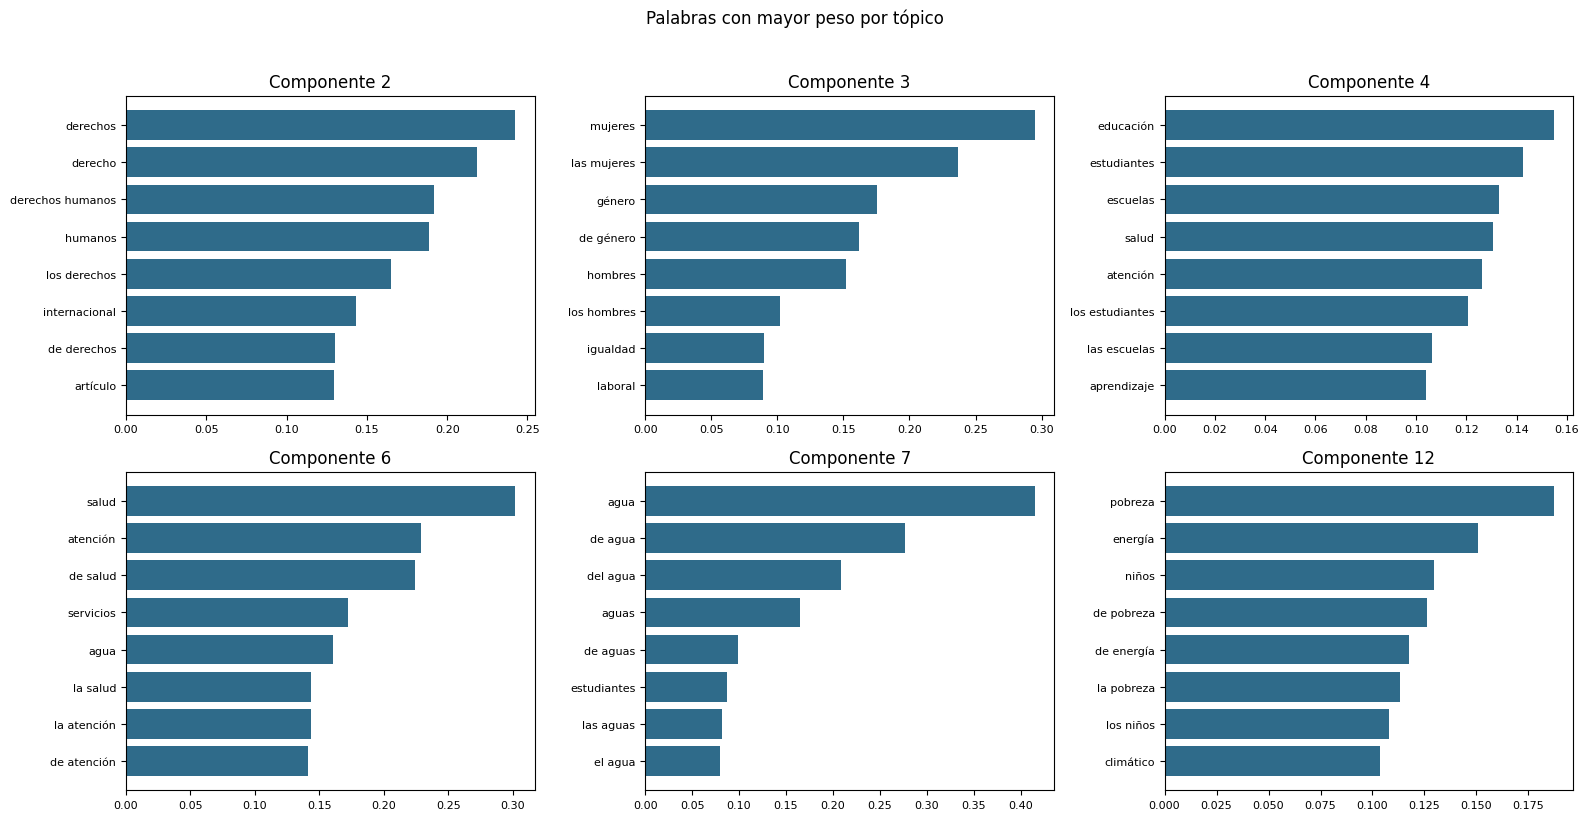

In [10]:
# Visualización de los tópicos y sus palabras más representativas
componentes_elegidos = [2, 3, 4, 6, 7, 12]
filas = []

# Bucle para obtener las palabras con mayor peso y los ODS más frecuentes para cada componente elegido
for c in componentes_elegidos:
    i = c - 1
    top_palabras = np.argsort(lsa.components_[i])[-10:][::-1]
    top_docs = np.argsort(X_train_lsa[:, i])[-30:][::-1]
    odss = y_train.iloc[top_docs].value_counts().head(3)
    filas.append({
        "componente": c,
        "palabras con mayor peso": ", ".join(terminos[top_palabras]),
        "ODS frecuentes (30 textos)": ", ".join(f"ODS {o}: {n}" for o, n in odss.items()),
    })

# visualización de la tabla de tópicos con sus palabras más representativas y los ODS más frecuentes
tabla_topicos = pd.DataFrame(filas).set_index("componente")
display(tabla_topicos)

#  Gráfico de barras horizontales para visualizar las palabras con mayor peso por tópico
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for c, ax in zip(componentes_elegidos, axes.flat):
    pesos = lsa.components_[c - 1]
    idx = np.argsort(pesos)[-8:]
    ax.barh(terminos[idx], pesos[idx], color="#2F6B8A")
    ax.set_title(f"Componente {c}")
    ax.tick_params(labelsize=8)
plt.suptitle("Palabras con mayor peso por tópico", y=1.02)
plt.tight_layout()
plt.show()

### Interpretación de seis tópicos

| Componente | Tema | Relación con los ODS |
|---:|---|---|
| 2 | Derechos, leyes e instituciones | ODS 16: paz, justicia e instituciones sólidas. |
| 3 | Género y trabajo | ODS 5, con cercanía a ODS 10 en solo 1 palabra. |
| 4 | Educación y salud | Mezcla de ODS 4 y ODS 3 en un 50/50. |
| 6 | Salud y atención médica | ODS 3: salud y bienestar. |
| 7 | Agua y saneamiento | ODS 6: agua limpia y saneamiento. |
| 12 | Clima y pobreza | ODS 1:  Fin de la pobreza, al ser un tema transversal comparte palabras en otros ODS. |

LSA recuperó 4 tópicos puros o casi puros (2, 3, 6 y 7) y 2 mixtos coherentes (4 y 12): suficiente para afirmar que la representación TF-IDF contiene señal semántica alineada con los ODS, con la salvedad de que los temas minoritarios se mezclan por el desbalance del corpus.


## 6. Clasificación con cuatro modelos

Se comparan cuatro clasificadores:

- **Regresión logística + SVD(100):** modelo lineal sencillo, usa la reducción para trabajar con 100 temas en vez de miles de palabras.
- **Árbol de decisión + SVD(100):** modelo sencillo e interpretable que trabaja sobre los 100 temas; sirve como contraste no lineal frente a los modelos lineales.
- **SVM lineal + SVD(100):** modelo lineal muy usado en textos, candidato principal con reducción; la regularización `C` controla el equilibrio entre ajuste y generalización.
- **SVM lineal + TF-IDF (referencia):** el mismo SVM sin reducción; sirve para medir cuánto se gana o se pierde al reducir la dimensión.

Los cuatro usan los mismos parámetros de `PARAMETROS_TFIDF` definidos en la sección 4. Se usa validación cruzada con 5 partes y se compara con **F1 macro**, que trata a todos los ODS por igual aunque unos tengan más textos que otros.


In [11]:
# Pasos comunes de texto: se reutiliza el diccionario PARAMETROS_TFIDF de la sección 4.
# Se usa clean_corpus de src (igual que la app) para que el pipeline guardado se pueda recargar.
def pasos_base():
    return [
        ("limpieza", FunctionTransformer(clean_corpus, validate=False)),
        ("tfidf", TfidfVectorizer(**PARAMETROS_TFIDF)),
    ]

# Modelo 1: regresión logística con reducción SVD
pipe_logistica = Pipeline(pasos_base() + [
    ("svd", TruncatedSVD(n_components=100, random_state=SEED)),
    ("modelo", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
])

# Modelo 2: arbol de decisión con reducción SVD
pipe_arbol = Pipeline(pasos_base() + [
    ("svd", TruncatedSVD(n_components=100, random_state=SEED)),
    ("modelo", DecisionTreeClassifier(max_depth=20, class_weight="balanced", random_state=SEED)),
])

# Modelo 3: SVM lineal con reducción SVD
pipe_svm = Pipeline(pasos_base() + [
    ("svd", TruncatedSVD(n_components=100, random_state=SEED)),
    ("modelo", LinearSVC(C=1, class_weight="balanced", random_state=SEED)),
])

# Modelo 4: SVM lineal sin reducción (referencia)
pipeline_svm_directa = Pipeline(pasos_base() + [
    ("modelo", LinearSVC(C=1, class_weight="balanced", random_state=SEED)),
])

# selección de modelos a comparar y definición de métricas de evaluación
modelos = {
    "Logística + SVD(100)": pipe_logistica,
    "Árbol de Decisión + SVD(100)": pipe_arbol,
    "SVM + SVD(100)": pipe_svm,
    "SVM + TF-IDF": pipeline_svm_directa,
}

,accuracy,f1_macro,f1_weighted
modelo,,,
SVM + TF-IDF,0.8918,0.8687,0.8904
SVM + SVD(100),0.8527,0.8206,0.8516
Logística + SVD(100),0.8387,0.8083,0.8402
Árbol de Decisión + SVD(100),0.6579,0.5945,0.6597


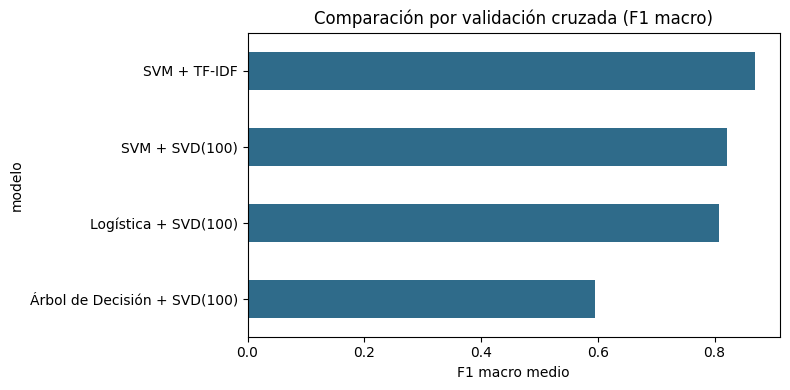

Modelo con reducción elegido: SVM + SVD(100)


In [12]:
# Esquema de validación: 5 particiones estratificadas (mantiene proporciones de ODS) con orden aleatorio
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
metricas = {"accuracy": "accuracy", "f1_macro": "f1_macro", "f1_weighted": "f1_weighted"}

# Bucle de entrenamiento y evaluación de cada partición con k=5 
filas = []
for nombre, modelo in modelos.items():
    r = cross_validate(modelo, X_train, y_train, cv=cv, scoring=metricas, n_jobs=1)
    filas.append({
        "modelo": nombre,
        "accuracy": r["test_accuracy"].mean(),
        "f1_macro": r["test_f1_macro"].mean(),
        "f1_weighted": r["test_f1_weighted"].mean(),
    })

# Construcción de la tabla de resultados ordenada de mayor a menor por F1-Macro
comparacion = (
    pd.DataFrame(filas)
    .set_index("modelo")
    .sort_values("f1_macro", ascending=False)
)
display(comparacion.round(4))

# Gráfico de barras horizontal ordenado por la métrica principal (F1 Macro)
comparacion["f1_macro"].sort_values().plot.barh(color="#2F6B8A", figsize=(8, 4))
plt.title("Comparación por validación cruzada (F1 macro)")
plt.xlabel("F1 macro medio")
plt.tight_layout()
plt.show()

# Se elige el mejor modelo que usa reducción (SVD) para la búsqueda de hiperparámetros
candidatos_reducidos = comparacion.loc[["Logística + SVD(100)", "SVM + SVD(100)", "Árbol de Decisión + SVD(100)"]]
# Seleccionar dinámicamente el nombre del modelo con mayor puntuación F1-Macro
mejor_reducido = candidatos_reducidos["f1_macro"].idxmax()
print("Modelo con reducción elegido:", mejor_reducido)


### Búsqueda de hiperparámetros

Se optimiza el modelo con reducción elegido arriba. Se prueban 12 combinaciones que cambian la dimensión SVD (100, 200, 300), la regularización `C`, los pesos de clase y los parámetros TF-IDF (`min_df`, `max_df`, bigramas). Cada una se evalúa con las mismas 5 partes, es decir 60 ajustes. Gana la de mejor F1 macro.


In [13]:
# Lista de configuraciones a probar (como en el análisis de referencia)
base_tfidf = {"tfidf__min_df": 3, "tfidf__max_df": 0.30, "tfidf__ngram_range": (1, 2)}
configuraciones = [
    {"svd__n_components": 100, "modelo__C": 1.0, "modelo__class_weight": "balanced", **base_tfidf},
    {"svd__n_components": 200, "modelo__C": 1.0, "modelo__class_weight": "balanced", **base_tfidf},
    {"svd__n_components": 300, "modelo__C": 1.0, "modelo__class_weight": "balanced", **base_tfidf},
    {"svd__n_components": 200, "modelo__C": 0.5, "modelo__class_weight": "balanced", **base_tfidf},
    {"svd__n_components": 200, "modelo__C": 2.0, "modelo__class_weight": "balanced", **base_tfidf},
    {"svd__n_components": 300, "modelo__C": 0.5, "modelo__class_weight": "balanced", **base_tfidf},
    {"svd__n_components": 300, "modelo__C": 2.0, "modelo__class_weight": "balanced", **base_tfidf},
    {"svd__n_components": 200, "modelo__C": 1.0, "modelo__class_weight": None, **base_tfidf},
    {"svd__n_components": 300, "modelo__C": 1.0, "modelo__class_weight": None, **base_tfidf},
    {"svd__n_components": 300, "modelo__C": 1.0, "modelo__class_weight": "balanced",
     "tfidf__min_df": 2, "tfidf__max_df": 0.50, "tfidf__ngram_range": (1, 2)},
    {"svd__n_components": 300, "modelo__C": 1.0, "modelo__class_weight": "balanced",
     "tfidf__min_df": 5, "tfidf__max_df": 0.50, "tfidf__ngram_range": (1, 2)},
    {"svd__n_components": 300, "modelo__C": 1.0, "modelo__class_weight": "balanced",
     "tfidf__min_df": 3, "tfidf__max_df": 0.80, "tfidf__ngram_range": (1, 1)},
]
param_grid = [{k: [v] for k, v in c.items()} for c in configuraciones]
print(f"12 configuraciones x 5 partes = 60 ajustes, más el reajuste final.")

# El estimador de la búsqueda es el modelo con reducción elegido en la celda anterior
pipe_reducido = {"Logística + SVD(100)": pipe_logistica, 
                 "SVM + SVD(100)": pipe_svm, 
                 "Árbol de Decisión + SVD(100)": pipe_arbol}[mejor_reducido]

# Búsqueda de hiperparámetros con validación cruzada (GridSearchCV)
busqueda = GridSearchCV(
    clone(pipe_reducido),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=1,
)
busqueda.fit(X_train, y_train)

# Resultados de la búsqueda de hiperparámetros
print("Mejor F1 macro en validación:", round(busqueda.best_score_, 4))
print("Mejores valores:", busqueda.best_params_)

# Visualización de los resultados de la búsqueda de hiperparámetros
display(pd.DataFrame(busqueda.cv_results_)[[
    "rank_test_score", "mean_test_score", "std_test_score",
    "param_svd__n_components", "param_modelo__C", "param_modelo__class_weight",
    "param_tfidf__min_df", "param_tfidf__max_df", "param_tfidf__ngram_range",
]].sort_values("rank_test_score"))

12 configuraciones x 5 partes = 60 ajustes, más el reajuste final.


Mejor F1 macro en validación: 0.8438
Mejores valores: {'modelo__C': 1.0, 'modelo__class_weight': 'balanced', 'svd__n_components': 300, 'tfidf__max_df': 0.8, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 1)}


,rank_test_score,mean_test_score,std_test_score,param_svd__n_components,param_modelo__C,param_modelo__class_weight,param_tfidf__min_df,param_tfidf__max_df,param_tfidf__ngram_range
11,1,0.843825,0.003588,300,1.0,balanced,3,0.8,"(1, 1)"
9,2,0.841801,0.006629,300,1.0,balanced,2,0.5,"(1, 2)"
5,3,0.840084,0.005058,300,0.5,balanced,3,0.3,"(1, 2)"
6,4,0.839961,0.006160,300,2.0,balanced,3,0.3,"(1, 2)"
2,5,0.839852,0.006259,300,1.0,balanced,3,0.3,"(1, 2)"
10,6,0.839421,0.005418,300,1.0,balanced,5,0.5,"(1, 2)"
8,7,0.837086,0.006757,300,1.0,None,3,0.3,"(1, 2)"
4,8,0.834768,0.007197,200,2.0,balanced,3,0.3,"(1, 2)"
1,9,0.833296,0.007150,200,1.0,balanced,3,0.3,"(1, 2)"
3,10,0.832300,0.007562,200,0.5,balanced,3,0.3,"(1, 2)"


## 7. Evaluación final con textos no vistos

Se entrena el mejor modelo con todo el entrenamiento y se prueba **una sola vez** con la prueba separada al inicio.


In [14]:
# con base a la búsqueda de hiperparámetros, se entrena el mejor modelo con todos los datos de entrenamiento y se evalúa en los datos de prueba
mejor_modelo = busqueda.best_estimator_
mejor_modelo.fit(X_train, y_train)

# Se realiza la predicción en los datos de prueba y se calculan las métricas de rendimiento
y_pred = mejor_modelo.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("F1 macro:", round(f1_score(y_test, y_pred, average='macro'), 4))
print("F1 ponderado:", round(f1_score(y_test, y_pred, average='weighted'), 4))
print("Textos en prueba:", len(y_test))

Accuracy: 0.8742
F1 macro: 0.8443
F1 ponderado: 0.8736
Textos en prueba: 1932


,precision,recall,f1-score,support
1,0.854,0.812,0.832,101.000
2,0.759,0.811,0.784,74.000
3,0.902,0.927,0.915,179.000
4,0.952,0.971,0.961,205.000
5,0.914,0.944,0.929,214.000
6,0.920,0.906,0.913,139.000
7,0.927,0.886,0.906,158.000
8,0.622,0.573,0.596,89.000
9,0.736,0.768,0.752,69.000
10,0.697,0.657,0.676,70.000


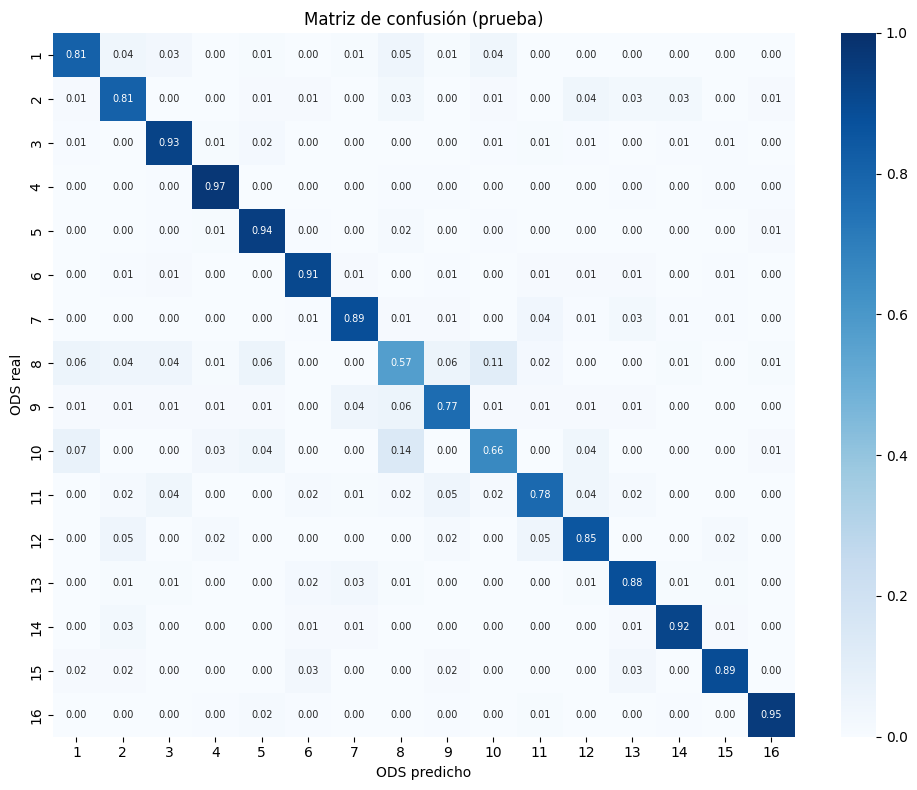

In [15]:
# Obtener la lista ordenada de todas las clases únicas (ODS) del conjunto de datos
etiquetas = sorted(y.unique())

# generar el reporte de clasificación y la matriz de confusión para evaluar el rendimiento del modelo en los datos de prueba
reporte = pd.DataFrame(classification_report(
    y_test, y_pred, labels=etiquetas, output_dict=True, zero_division=0,
)).T
display(reporte.round(3))

# cálculo de la matriz de confusión normalizada y visualización con un mapa de calor
matriz = confusion_matrix(y_test, y_pred, labels=etiquetas, normalize="true")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matriz, cmap="Blues", vmin=0, vmax=1, annot=True, fmt=".2f",
            xticklabels=etiquetas, yticklabels=etiquetas, annot_kws={"size": 7}, ax=ax)
ax.set(title="Matriz de confusión (prueba)", xlabel="ODS predicho", ylabel="ODS real")
plt.tight_layout()
plt.show()

### Cuatro ejemplos de la prueba

Se muestran cuatro textos de la prueba con su etiqueta real y la predicción del modelo.


In [16]:
# Diccionaario para mostrar los nombres de los ODS en lugar de solo los números
NOMBRES = {
    1: "Fin de la pobreza", 2: "Hambre cero", 3: "Salud y bienestar",
    4: "Educación de calidad", 5: "Igualdad de género", 6: "Agua limpia y saneamiento",
    7: "Energía asequible", 8: "Trabajo decente", 9: "Industria e innovación",
    10: "Reducción de desigualdades", 11: "Ciudades sostenibles", 12: "Producción responsable",
    13: "Acción por el clima", 14: "Vida submarina", 15: "Vida terrestre",
    16: "Paz y justicia",
}

# muestra aleatoria de 4 textos de prueba con sus ODS reales y predichos, indicando si hubo acierto o no
muestra = pd.DataFrame({"texto": X_test, "real": y_test, "predicho": y_pred})
muestra = muestra.sample(n=4, random_state=SEED+2).reset_index(drop=True)
muestra["real_nombre"] = muestra["real"].map(NOMBRES)
muestra["predicho_nombre"] = muestra["predicho"].map(NOMBRES)
muestra["acierto"] = muestra["real"] == muestra["predicho"]
muestra["texto"] = muestra["texto"].str.replace(r"\s+", " ", regex=True).str.slice(0, 400)
display(muestra[["real", "real_nombre", "predicho", "predicho_nombre", "acierto", "texto"]])


,real,real_nombre,predicho,predicho_nombre,acierto,texto
0,7,Energía asequible,7,Energía asequible,True,"La mayoría de los países dependen, al menos pa..."
1,7,Energía asequible,7,Energía asequible,True,"En su caso, los combustibles alternativos a la..."
2,16,Paz y justicia,16,Paz y justicia,True,"En este artículo, el objetivo es repasar el an..."
3,11,Ciudades sostenibles,11,Ciudades sostenibles,True,El banco central también busca reducir aún más...


### Conclusión de la evaluación

El pipeline final (TF-IDF con unigramas + SVD 300 + SVM lineal) obtuvo sobre los 1.932 textos de prueba **accuracy 0,8742**, **F1 macro 0,8443** y **F1 ponderado 0,8736**. El F1 macro de prueba (0,8443) coincide con el de validación cruzada (0,8438), lo que indica una generalización estable sin sobreajuste.

La referencia sin reducción (SVM + TF-IDF directo, F1 macro 0,8687) quedó ~2,5 puntos por encima: ese es el costo medido de comprimir miles de términos en 300 dimensiones, a cambio de un modelo liviano y conectado con el análisis LSA. Entre los modelos con reducción, el SVM (0,8206) superó a la regresión logística (0,8083) y ampliamente al árbol de decisión (0,5945), lo que confirma que los modelos lineales dominan en este problema de texto.

Por clase, los mejores desempeños están en los ODS 4 (0,961) y 16 (0,960), y los peores en los ODS 8 (0,596), 10 (0,676) y 9 (0,752): son clases escasas con vocabulario económico compartido (empleo, industria, desigualdad), las mismas que el análisis de distribución ya anticipaba como difíciles.


# 8. Serialización y verificación del pipeline



In [17]:
import hashlib
import json
from datetime import datetime, timezone

import joblib

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "pipeline_ods.joblib"
METADATA_PATH = MODELS_DIR / "metadata_modelo.json"

# El mejor estimador de la búsqueda ya quedó ajustado con todo el entrenamiento
pipeline_final = busqueda.best_estimator_
joblib.dump(pipeline_final, MODEL_PATH, compress=3)

# Verificación: el modelo recargado predice igual que el original
modelo_recargado = joblib.load(MODEL_PATH)
assert np.array_equal(
    modelo_recargado.predict(X_test.iloc[:50]),
    pipeline_final.predict(X_test.iloc[:50]),
)

# Huellas y metadatos para trazabilidad
huella_datos = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
huella_modelo = hashlib.sha256(MODEL_PATH.read_bytes()).hexdigest()
mejores = busqueda.best_params_
clases_modelo = pipeline_final.named_steps["modelo"].classes_

metadata_modelo = {
    "fecha_generacion_utc": datetime.now(timezone.utc).isoformat(),
    "archivo_datos_sha256": huella_datos,
    "archivo_modelo_sha256": huella_modelo,
    "clases": [int(x) for x in clases_modelo],
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "hiperparametros": {
        "tfidf_ngram_range": list(mejores["tfidf__ngram_range"]),
        "tfidf_min_df": int(mejores["tfidf__min_df"]),
        "tfidf_max_df": float(mejores["tfidf__max_df"]),
        "svd_n_components": int(mejores["svd__n_components"]),
        "svm_C": float(mejores["modelo__C"]),
        "class_weight": mejores["modelo__class_weight"],
    },
    "metricas_test": {
        "accuracy": round(float(accuracy_score(y_test, y_pred)), 4),
        "f1_macro": round(float(f1_score(y_test, y_pred, average="macro")), 4),
        "f1_weighted": round(float(f1_score(y_test, y_pred, average="weighted")), 4),
    },
    "limitacion": "El conjunto de entrenamiento no contiene ejemplos del ODS 17.",
}

with METADATA_PATH.open("w", encoding="utf-8") as archivo:
    json.dump(metadata_modelo, archivo, ensure_ascii=False, indent=2)

# Inventario de entregables del proyecto
entregables = {
    "Notebook ejecutado": PROJECT_ROOT / "proyecto_ods_final.ipynb",
    "Pipeline serializado": MODEL_PATH,
    "Metadatos del modelo": METADATA_PATH,
    "Aplicación Streamlit": PROJECT_ROOT / "app.py",
    "Dependencias": PROJECT_ROOT / "requirements.txt",
}
for nombre, ruta in entregables.items():
    print(f"{'OK ' if ruta.exists() else 'FALTA'} {nombre}: {ruta.relative_to(PROJECT_ROOT)}")
assert all(r.exists() for r in entregables.values()), "Falta al menos un entregable"

print(f"Tamaño del modelo: {MODEL_PATH.stat().st_size / 1024**2:.1f} MB")
print("Verificación de recarga superada sobre 50 textos de prueba.")


OK  Notebook ejecutado: proyecto_ods_final.ipynb
OK  Pipeline serializado: models\pipeline_ods.joblib
OK  Metadatos del modelo: models\metadata_modelo.json
OK  Aplicación Streamlit: app.py
OK  Dependencias: requirements.txt
Tamaño del modelo: 27.3 MB
Verificación de recarga superada sobre 50 textos de prueba.


## 9. Conclusiones

**Actividad 1 (TF-IDF + pipeline).** La limpieza sencilla (URLs, espacios, minúsculas) y TF-IDF con `min_df=3` produjeron una matriz de ~7.700 textos lista para LSA y clasificación, todo encapsulado en pipelines reproducibles que hoy reutiliza la aplicación.

**Actividad 2 (LSA).** Con 15 componentes se interpretaron 6 tópicos coherentes (derechos, género, educación/salud, salud, agua, clima/pobreza), varios casi puros frente a las etiquetas reales (componentes 2 y 6 con 30/30). Los tópicos mixtos reflejan relaciones reales entre ODS, no fallas del método.

**Actividad 3 (clasificación).** De 4 modelos comparados con validación cruzada de 5 partes, el SVM lineal + SVD ganó entre los reducidos (0,8206), seguido de la regresión logística (0,8083); el árbol (0,5945) confirmó que lo lineal domina en texto. La búsqueda de 12 configuraciones eligió SVD 300, `C=1.0`, pesos balanceados y unigramas (CV 0,8438). La regresión logística queda como alternativa sencilla vista en clase, a ~1 punto del SVM.

**Actividad 4 (evaluación).** Una sola pasada sobre prueba: accuracy 0,8742, F1 macro 0,8443 y ponderado 0,8736, con 4 ejemplos individuales mostrados. La cercanía con validación (0,8438) respalda la generalización.

**Limitaciones.** No hay datos del ODS 17 (alcance: ODS 1–16); los ODS 8, 9 y 10 rinden menos por poco soporte y vocabulario compartido; una etiqueta única simplifica textos multitema; los márgenes del SVM no son probabilidades. Es un apoyo exploratorio, no sustituto de expertos.

**Cómo repetirlo.** Instalar `requirements.txt`, abrir este notebook desde la raíz del proyecto y ejecutar todas las celdas en orden. La aplicación se inicia con `streamlit run app.py` y consume el mismo pipeline guardado.


#####  Presentado por:
- Diego Andrés Valle Tapia
- Jhon Alexander Rojas Guerrero